In [ ]:
import pandas
import matplotlib.pyplot as plt
import plotly.express as px
import citibike_module

In [ ]:
bike = citibike_module.CitiBike()
data = bike.retrieve_data()

[{'eightd_has_key_dispenser': False, 'short_name': '2009.04', 'lat': 40.6115, 'rental_methods': ['KEY', 'CREDITCARD'], 'rental_uris': {'ios': 'https://bkn.lft.to/lastmile_qr_scan', 'android': 'https://bkn.lft.to/lastmile_qr_scan'}, 'station_id': '2124426307973079924', 'has_kiosk': False, 'external_id': '2124426307973079924', 'name': 'Shore Rd & 4 Ave', 'capacity': 12, 'station_type': 'classic', 'region_id': '71', 'electric_bike_surcharge_waiver': False, 'eightd_station_services': [], 'lon': -74.03513}, {'eightd_has_key_dispenser': False, 'short_name': '8775.03', 'lat': 40.87689, 'rental_methods': ['KEY', 'CREDITCARD'], 'rental_uris': {'ios': 'https://bkn.lft.to/lastmile_qr_scan', 'android': 'https://bkn.lft.to/lastmile_qr_scan'}, 'station_id': '2171903488884523500', 'has_kiosk': False, 'external_id': '2171903488884523500', 'name': 'Hull Ave & E 209 St', 'capacity': 14, 'station_type': 'classic', 'region_id': '71', 'electric_bike_surcharge_waiver': False, 'eightd_station_services': [], 

<img src=https://images.ctfassets.net/p6ae3zqfb1e3/7ezkCCnEreb7FcbhD62UCi/5ef46f5743416afe10fbbb1696b7200a/Screenshot_2025-12-23_at_10.35.29%C3%A2__AM.png>

In [3]:
df_all = pandas.DataFrame(data)


In [4]:
df_all.head()

,eightd_has_key_dispenser,short_name,lat,rental_methods,rental_uris,station_id,has_kiosk,external_id,name,capacity,station_type,region_id,electric_bike_surcharge_waiver,eightd_station_services,lon
0,False,2009.04,40.611500,"[KEY, CREDITCARD]","{'ios': 'https://bkn.lft.to/lastmile_qr_scan',...",2124426307973079924,False,2124426307973079924,Shore Rd & 4 Ave,12,classic,71,False,[],-74.035130
1,False,8775.03,40.876890,"[KEY, CREDITCARD]","{'ios': 'https://bkn.lft.to/lastmile_qr_scan',...",2171903488884523500,False,2171903488884523500,Hull Ave & E 209 St,14,classic,71,False,[],-73.874440
2,False,7821.01,40.814469,"[KEY, CREDITCARD]","{'ios': 'https://bkn.lft.to/lastmile_qr_scan',...",ebae0b66-e463-4ded-9b7a-43c0aca9b37a,True,ebae0b66-e463-4ded-9b7a-43c0aca9b37a,Morris Ave & E 142 St,23,classic,71,False,[],-73.924963
3,False,6798.01,40.762814,"[KEY, CREDITCARD]","{'ios': 'https://bkn.lft.to/lastmile_qr_scan',...",0fa27bd7-b182-4e7a-b5bb-90f4249cb368,True,0fa27bd7-b182-4e7a-b5bb-90f4249cb368,34 Ave & 21 St,23,classic,71,False,[],-73.934286
4,False,7141.07,40.775794,"[KEY, CREDITCARD]","{'ios': 'https://bkn.lft.to/lastmile_qr_scan',...",66dd4ccc-0aca-11e7-82f6-3863bb44ef7c,True,66dd4ccc-0aca-11e7-82f6-3863bb44ef7c,Central Park W & W 72 St,51,classic,71,False,[],-73.976206


Filter to desired columns & summarize shape

In [5]:
df = df_all[["capacity","name",'has_kiosk','station_type','region_id','lat','lon','station_id']]
df.head()

,capacity,name,has_kiosk,station_type,region_id,lat,lon,station_id
0,12,Shore Rd & 4 Ave,False,classic,71,40.611500,-74.035130,2124426307973079924
1,14,Hull Ave & E 209 St,False,classic,71,40.876890,-73.874440,2171903488884523500
2,23,Morris Ave & E 142 St,True,classic,71,40.814469,-73.924963,ebae0b66-e463-4ded-9b7a-43c0aca9b37a
3,23,34 Ave & 21 St,True,classic,71,40.762814,-73.934286,0fa27bd7-b182-4e7a-b5bb-90f4249cb368
4,51,Central Park W & W 72 St,True,classic,71,40.775794,-73.976206,66dd4ccc-0aca-11e7-82f6-3863bb44ef7c


In [6]:
df.shape

(2406, 8)

Check for duplicated stations

In [7]:
df['station_id'].nunique() == df['station_id'].count()

np.True_

Check for missing data

In [8]:
#How many rows have the missing data?
df.isna().values.sum()

np.int64(13)

In [9]:
#Which columns have the missing data?
df.isnull().sum()

capacity         0
name             0
has_kiosk        0
station_type     0
region_id       13
lat              0
lon              0
station_id       0
dtype: int64

In [10]:
#Drop missing data
df_nona = df.dropna()

Check for correct data types

In [11]:
df_nona.info()

<class 'pandas.DataFrame'>
Index: 2393 entries, 0 to 2405
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   capacity      2393 non-null   int64  
 1   name          2393 non-null   str    
 2   has_kiosk     2393 non-null   bool   
 3   station_type  2393 non-null   str    
 4   region_id     2393 non-null   str    
 5   lat           2393 non-null   float64
 6   lon           2393 non-null   float64
 7   station_id    2393 non-null   str    
dtypes: bool(1), float64(2), int64(1), str(4)
memory usage: 151.9 KB


In [12]:
df_nona['region_id'].unique()
#region_id should be integer

<StringArray>
['71', '70', '311']
Length: 3, dtype: str

In [13]:
df_final = df_nona.astype({"region_id": 'int'})

In [14]:
#Add categorical region_id field
df_final['region_id_cat'] = df['region_id'].astype('str')

In [15]:
df_final.info()

<class 'pandas.DataFrame'>
Index: 2393 entries, 0 to 2405
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   capacity       2393 non-null   int64  
 1   name           2393 non-null   str    
 2   has_kiosk      2393 non-null   bool   
 3   station_type   2393 non-null   str    
 4   region_id      2393 non-null   int64  
 5   lat            2393 non-null   float64
 6   lon            2393 non-null   float64
 7   station_id     2393 non-null   str    
 8   region_id_cat  2393 non-null   str    
dtypes: bool(1), float64(2), int64(2), str(4)
memory usage: 170.6 KB


Visually explore data

In [16]:
df_final.describe()

,capacity,region_id,lat,lon
count,2393.000000,2393.000000,2393.000000,2393.000000
mean,29.908901,73.776431,40.744381,-73.947957
std,17.606842,25.817968,0.064276,0.048262
min,0.000000,70.000000,40.611240,-74.098110
25%,20.000000,71.000000,40.697842,-73.983688
50%,24.000000,71.000000,40.738920,-73.945151
75%,34.000000,71.000000,40.781721,-73.911259
max,123.000000,311.000000,40.912390,-73.832260


In [17]:
df_final.value_counts()

capacity  name                           has_kiosk  station_type  region_id  lat        lon         station_id                            region_id_cat
12        Shore Rd & 4 Ave               False      classic       71         40.611500  -74.035130  2124426307973079924                   71               1
14        Hull Ave & E 209 St            False      classic       71         40.876890  -73.874440  2171903488884523500                   71               1
23        Morris Ave & E 142 St          True       classic       71         40.814469  -73.924963  ebae0b66-e463-4ded-9b7a-43c0aca9b37a  71               1
          34 Ave & 21 St                 True       classic       71         40.762814  -73.934286  0fa27bd7-b182-4e7a-b5bb-90f4249cb368  71               1
51        Central Park W & W 72 St       True       classic       71         40.775794  -73.976206  66dd4ccc-0aca-11e7-82f6-3863bb44ef7c  71               1
                                                               

In [18]:
df_final['station_type'].unique()
#Station type does not vary

<StringArray>
['classic']
Length: 1, dtype: str

In [19]:
#Prepare data aggregation 1
kiosk_data = df_final.groupby('has_kiosk').sum(numeric_only=True).reset_index()
kiosk_data['has_kiosk_lab'] = kiosk_data['has_kiosk'].apply(lambda x: "Yes" if x else "No")
kiosk_data.head()


,has_kiosk,capacity,region_id,lat,lon,has_kiosk_lab
0,False,3324,14843,8389.812706,-15235.184606,No
1,True,68248,161704,89111.490784,-161722.276155,Yes


In [20]:
#Prepare data aggregation 2
region_data = df_final.groupby('region_id_cat').sum(numeric_only=True).reset_index()
region_data.head()

,region_id_cat,capacity,has_kiosk,region_id,lat,lon
0,311,582,27,8708,1140.830795,-2072.918016
1,70,1401,53,5320,3094.612130,-5628.696536
2,71,69589,2107,162519,93265.860565,-169255.846209


Text(0.5, 0.98, 'CitiBike Stations')

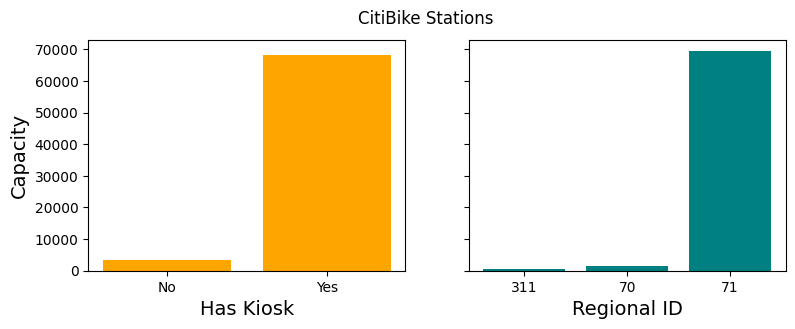

In [41]:
#Explore Counts of capacity by region_id, has_kiosk, and station_type

fig, axs = plt.subplots(1,2, figsize=(9, 3), sharey=True)
axs[0].bar(kiosk_data['has_kiosk_lab'], kiosk_data['capacity'], color="orange")
axs[1].bar(region_data['region_id_cat'], region_data['capacity'], color="teal")
axs[0].set_xlabel('Has Kiosk', fontsize=14)
axs[1].set_xlabel('Regional ID', fontsize=14)
axs[1].set_xlabel('Regional ID', fontsize=14)
axs[0].set_ylabel('Capacity', fontsize=14)
fig.align_labels() 
fig.suptitle('CitiBike Stations')

Visualize Bike Stations Geographically

In [32]:
df_final.head(2)

,capacity,name,has_kiosk,station_type,region_id,lat,lon,station_id,region_id_cat
0,12,Shore Rd & 4 Ave,False,classic,71,40.61150,-74.03513,2124426307973079924,71
1,14,Hull Ave & E 209 St,False,classic,71,40.87689,-73.87444,2171903488884523500,71


In [ ]:
fig = px.scatter_map(df_final, lat="lat", lon="lon", hover_name="station_id", hover_data=["name", "region_id", "capacity"],
                        color="region_id_cat", zoom=8, height=600)
#color_discrete_sequence=["fuchsia"]
fig.update_layout(map_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()